In [2]:
# Celda 1 — Importar librerías
# En Python, "importar" es como agregar librerías en Java

import pandas as pd          # para manejar datos (tablas)
import matplotlib.pyplot as plt  # para hacer gráficas
import seaborn as sns        # para gráficas más bonitas
import warnings
warnings.filterwarnings('ignore')  # oculta mensajes de advertencia

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [3]:
# Celda 2 — Cargar el dataset
df = pd.read_excel('../../data/raw/customer_data.xlsx')

print(f"✅ Dataset cargado correctamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

✅ Dataset cargado correctamente
   Filas    : 99,457
   Columnas : 4


In [4]:
# Celda 4 — Inspección inicial
# .info() en Python es como toString() en Java pero para toda la tabla

print("=== INFORMACIÓN GENERAL ===")
print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")
print()
df.info()

=== INFORMACIÓN GENERAL ===
Filas    : 99,457
Columnas : 4

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     99457 non-null  str    
 1   gender          99457 non-null  str    
 2   age             99338 non-null  float64
 3   payment_method  99457 non-null  str    
dtypes: float64(1), str(3)
memory usage: 3.0 MB


In [6]:
# Celda 5 — Verificar nulos y tipos de datos

print("=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())

print()
print("=== ¿CUÁNTOS NULOS TIENE age? ===")
nulos_age = df['age'].isnull().sum()
print(f"Filas con age vacío: {nulos_age}")
print(f"Porcentaje: {nulos_age/len(df)*100:.2f}%")

=== VALORES NULOS POR COLUMNA ===
customer_id         0
gender              0
age               119
payment_method      0
dtype: int64

=== ¿CUÁNTOS NULOS TIENE age? ===
Filas con age vacío: 119
Porcentaje: 0.12%


In [7]:
# Celda 6 — Limpieza de datos

# 1. Eliminar filas donde age esté vacío
# (son tan pocas que no afecta el análisis)
df = df.dropna(subset=['age'])

# 2. Convertir age de float64 a entero
# (nadie tiene 28.0 años, debe ser 28)
df['age'] = df['age'].astype(int)

# 3. Estandarizar texto — quitar espacios y capitalizar
# (evita que "male" y "Male" se cuenten como cosas diferentes)
df['gender'] = df['gender'].str.strip().str.title()
df['payment_method'] = df['payment_method'].str.strip().str.title()

# Verificar resultado
print("=== DESPUÉS DE LA LIMPIEZA ===")
print(f"Filas restantes : {len(df):,}")
print(f"Nulos restantes : {df.isnull().sum().sum()}")
print()
print("Tipo de dato de age:", df['age'].dtype)
print()
print("Valores únicos en gender:")
print(df['gender'].value_counts())
print()
print("Valores únicos en payment_method:")
print(df['payment_method'].value_counts())

=== DESPUÉS DE LA LIMPIEZA ===
Filas restantes : 99,338
Nulos restantes : 0

Tipo de dato de age: int64

Valores únicos en gender:
gender
Female    59412
Male      39926
Name: count, dtype: int64

Valores únicos en payment_method:
payment_method
Cash           44397
Credit Card    34898
Debit Card     20043
Name: count, dtype: int64


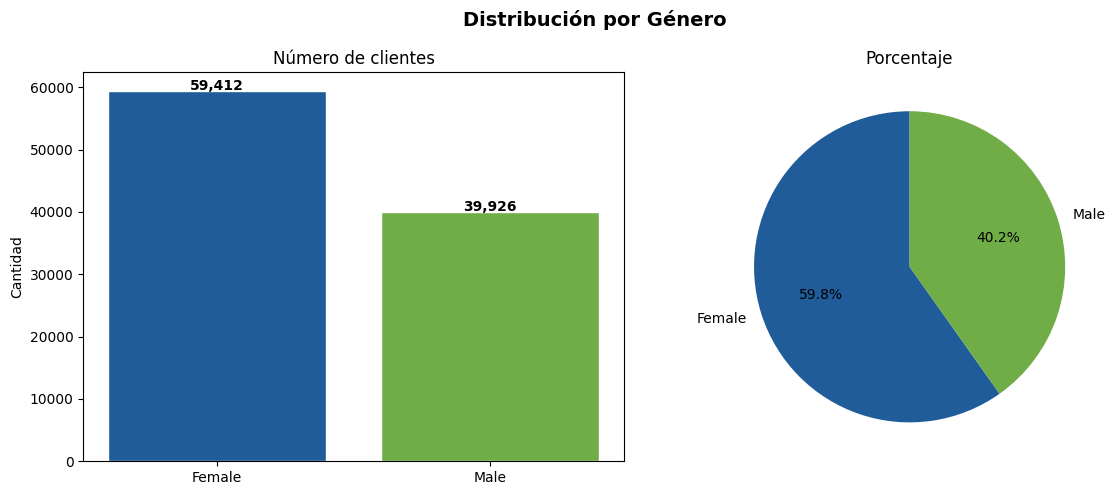

In [8]:
# Celda 7 — Gráfica: distribución por género

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución por Género', fontsize=14, fontweight='bold')

conteo = df['gender'].value_counts()

# Gráfica de barras
axes[0].bar(conteo.index, conteo.values, color=['#1F5C99', '#70AD47'], edgecolor='white')
axes[0].set_title('Número de clientes')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Gráfica de pastel
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=['#1F5C99', '#70AD47'], startangle=90)
axes[1].set_title('Porcentaje')

plt.tight_layout()

from pathlib import Path
output_dir = Path('../../reports/figures')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / 'grafica_genero.png', dpi=150, bbox_inches='tight')
plt.show()